In [4]:
'''
Group Project Part 2 - Heart Disease Prediction
Hyperparameter Tuning, Final Model Evaluation, and Ethical Considerations
Team: Group 5 - Tevin Parboosingh, Mukul Kumar Dhali, Neviar Rawlinson, Chandrashekar Reddy Mothukupally
PhDAI-732: Fundamentals of AI-Enabled Systems

Run each cell in order.

Data Loading and Preprocessing (from Part 1)
Model Training - Logistic Regression, KNN, SVM
Hyperparameter Tuning with GridSearchCV
Final Model Evaluation and Comparison
'''

'\nGroup Project Part 2 - Heart Disease Prediction\nHyperparameter Tuning, Final Model Evaluation, and Ethical Considerations\nTeam: Group 5 - Tevin Parboosingh, Mukul Kumar Dhali, Neviar Rawlinson, Chandrashekar Reddy Mothukupally\nPhDAI-732: Fundamentals of AI-Enabled Systems\n\nRun each cell in order.\n\nData Loading and Preprocessing (from Part 1)\nModel Training - Logistic Regression, KNN, SVM\nHyperparameter Tuning with GridSearchCV\nFinal Model Evaluation and Comparison\n'

In [5]:
# Prerequisites
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("All libraries imported successfully.")

All libraries imported successfully.


# Data Loading and Preprocessing

In [6]:
# Loading the Heart Disease UCI dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=columns, na_values='?')

# Binarize target
df['target'] = (df['target'] > 0).astype(int)

# Handle missing values
df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())

print("Dataset loaded and cleaned.")
print("Shape:", df.shape)
print("Target distribution:")
print(df['target'].value_counts())

Dataset loaded and cleaned.
Shape: (303, 14)
Target distribution:
target
0    164
1    139
Name: count, dtype: int64


In [7]:
# Features and target
feature_cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
                'ca', 'thal']

X = df[feature_cols].values
y = df['target'].values

# Train test split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

Training set: (242, 13)
Test set: (61, 13)


# Hyperparameter Tuning with GridSearchCV
Testing optimal parameters for all three models before final evaluation

In [8]:
# GridSearchCV for Logistic Regression
print("Tuning Logistic Regression...")
lr_params = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), lr_params, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train)

print(f"Best LR params: {lr_grid.best_params_}")
print(f"Best LR CV accuracy: {lr_grid.best_score_:.4f}")

Tuning Logistic Regression...
Best LR params: {'C': 1.0, 'penalty': 'l1', 'solver': 'liblinear'}
Best LR CV accuracy: 0.8345


In [9]:
# GridSearchCV for KNN
print("\nTuning KNN...")
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)

print(f"Best KNN params: {knn_grid.best_params_}")
print(f"Best KNN CV accuracy: {knn_grid.best_score_:.4f}")


Tuning KNN...
Best KNN params: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Best KNN CV accuracy: 0.8430


In [10]:
# GridSearchCV for SVM
print("\nTuning SVM...")
svm_params = {
    'C': [0.1, 1.0, 10.0, 100.0],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(SVC(random_state=42, probability=True), svm_params, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)

print(f"Best SVM params: {svm_grid.best_params_}")
print(f"Best SVM CV accuracy: {svm_grid.best_score_:.4f}")


Tuning SVM...
Best SVM params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM CV accuracy: 0.8304


#  Final Model Evaluation - comparing all three tuned models on the test set

In [11]:
# Evaluate all three best models on test set
models = {
    'Logistic Regression': lr_grid.best_estimator_,
    'KNN': knn_grid.best_estimator_,
    'SVM': svm_grid.best_estimator_
}

results = {}

print("=== Final Model Evaluation on Test Set ===\n")
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1, 'auc': auc,
        'y_pred': y_pred, 'y_prob': y_prob
    }

    print(f"{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {auc:.4f}")
    print()

=== Final Model Evaluation on Test Set ===

Logistic Regression:
  Accuracy:  0.8689
  Precision: 0.8125
  Recall:    0.9286
  F1 Score:  0.8667
  ROC-AUC:   0.9448

KNN:
  Accuracy:  0.8852
  Precision: 0.8000
  Recall:    1.0000
  F1 Score:  0.8889
  ROC-AUC:   0.9232

SVM:
  Accuracy:  0.8852
  Precision: 0.8621
  Recall:    0.8929
  F1 Score:  0.8772
  ROC-AUC:   0.9470



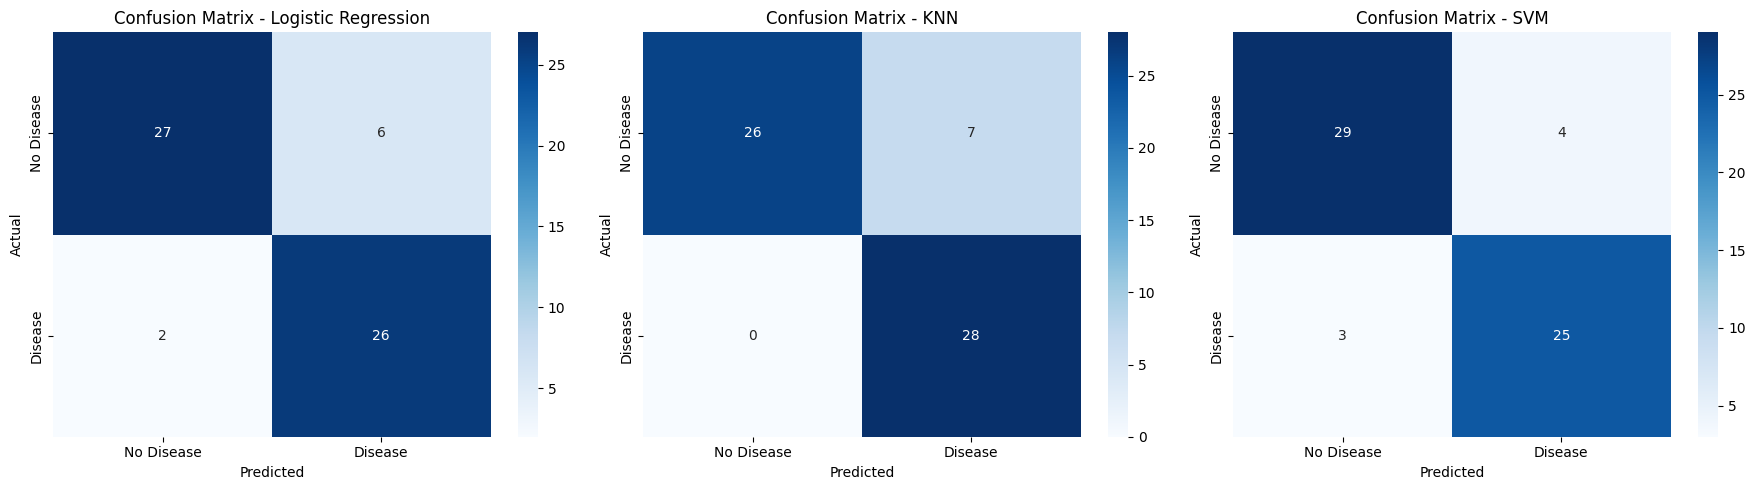

Confusion matrices saved.


In [12]:
# Confusion matrices for all three models

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'], ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix - {name}')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved.")

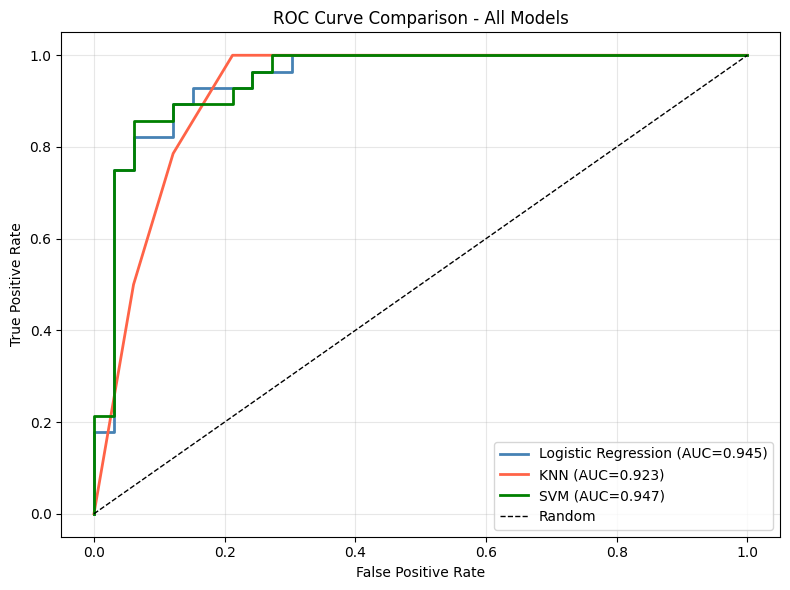

ROC curves saved.


In [13]:
# ROC curves for all three models

plt.figure(figsize=(8, 6))
colors = ['steelblue', 'tomato', 'green']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={res['auc']:.3f})")

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - All Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curves saved.")

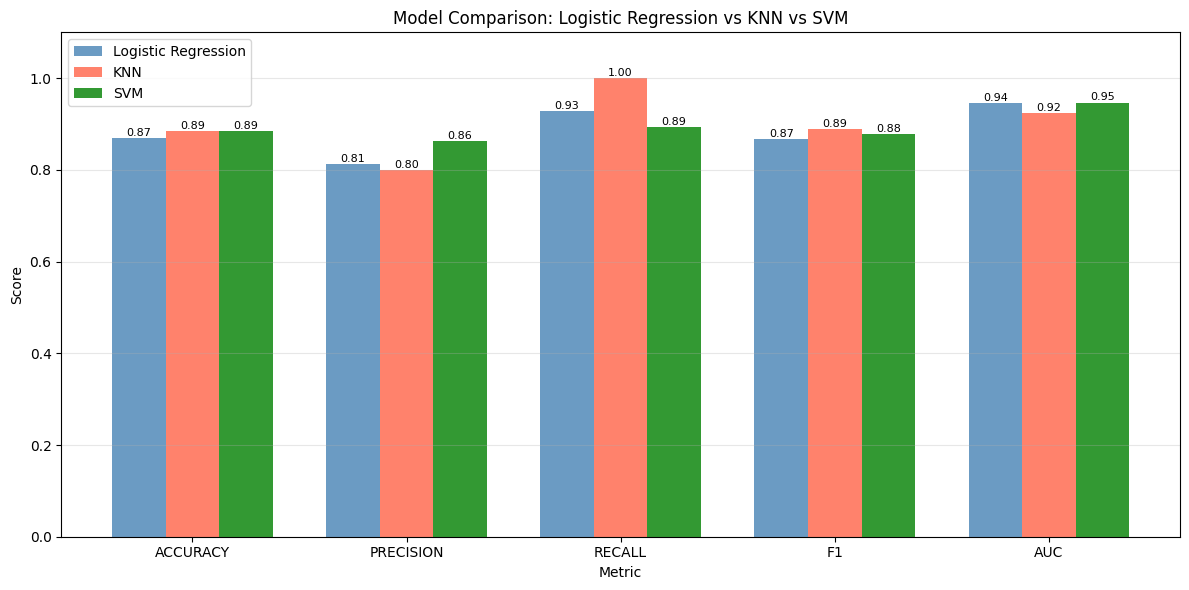

Model comparison saved.

All outputs generated. Bring back the metrics for the report.


In [14]:
# Model comparison bar chart

metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
x = np.arange(len(metrics))
width = 0.25
colors = ['steelblue', 'tomato', 'green']

fig, ax = plt.subplots(figsize=(12, 6))

for idx, (name, res) in enumerate(results.items()):
    values = [res[m] for m in metrics]
    bars = ax.bar(x + idx*width, values, width, label=name, color=colors[idx], alpha=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.2f}', ha='center', fontsize=8)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Logistic Regression vs KNN vs SVM')
ax.set_xticks(x + width)
ax.set_xticklabels([m.upper() for m in metrics])
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Model comparison saved.")

print("\nAll outputs generated. Bring back the metrics for the report.")